In [58]:
from diffrax import ODETerm
from jax.scipy.stats import norm,poisson
import diffrax
import jax.numpy as jnp
import jax
import matplotlib.pyplot as plt

from time import perf_counter
from algorithms.svgd import svgd
from utilities.helpers import effective_sample_size,autocorr_new,gr_statistic

jax.config.update('jax_platform_name', 'cpu')

print(jax.devices())

[CpuDevice(id=0)]


In [59]:
beta = jnp.log(0.4)
eta = jnp.log(1/7)
gamma = jnp.log(1/14) #0.07
q= jnp.log(0.1)
mu = jnp.log(0.01)

par_true = jnp.array([beta,eta,gamma,q,mu])

t_vec = jnp.linspace(0,100,100)

def SEIR(t,y,args):
  beta,eta,gamma,q,mu = args

  beta = jnp.exp(beta)
  eta = jnp.exp(eta)
  gamma = jnp.exp(gamma)
  q = jnp.exp(q)
  mu = jnp.exp(mu)

  S,E,I,R = y
  N = S+E+I+R

  dS = - beta * ((E + q * I)/N) * S
  dE = beta * ((E + q * I)/N) * S - eta*E - gamma * E
  dI = eta * E - gamma * I - mu * I
  dR = gamma * E + gamma * I


  return jnp.array([dS,dE,dI,dR])

In [60]:
def model(ts,y0,par):
  solution = diffrax.diffeqsolve(
            ODETerm(SEIR),
            diffrax.Tsit5(),
            t0=ts[0],
            t1=ts[-1],
            dt0=ts[1] - ts[0],
            y0=y0,
            args=par,
            saveat=diffrax.SaveAt(ts=t_vec)
        )
  return solution.ys

rng_key = jax.random.PRNGKey(0)

y_true = model(t_vec,jnp.array([1000,1.,1.,0]),(beta,eta,gamma,q,mu))

key = jax.random.key(0)

key,I_noise_key = jax.random.split(key)
data_newI = jax.random.poisson(I_noise_key,jnp.exp(eta) * y_true[:,1] + 0.005)

key,D_noise_key = jax.random.split(key)
data_newD = jax.random.poisson(D_noise_key,jnp.exp(mu) * y_true[:,2] + 0.005)

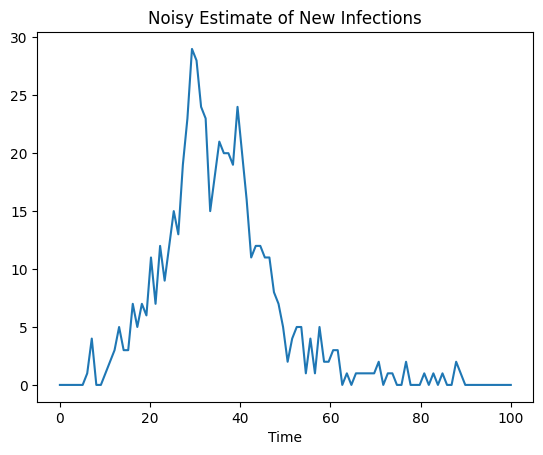

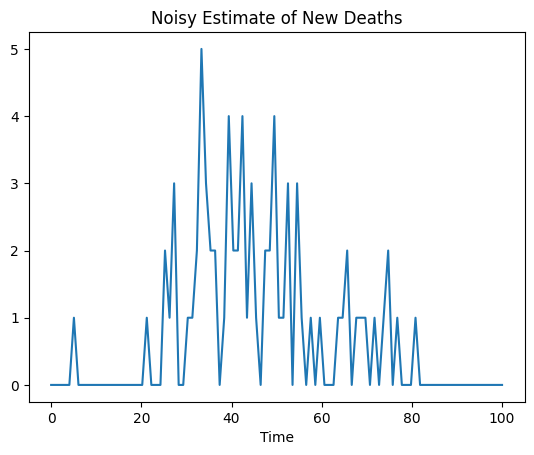

In [61]:
plt.title('Noisy Estimate of New Infections')
plt.plot(t_vec,data_newI)
plt.xlabel('Time')
plt.show()

plt.title('Noisy Estimate of New Deaths')
plt.xlabel('Time')
plt.plot(t_vec,data_newD)
plt.show()

In [62]:
def log_likelihood(par):
  beta,eta,gamma,q,mu = par
  model_output = model(t_vec,jnp.array([1000.,1.,1.,0.]),(beta,eta,gamma,q,mu))
  return jnp.sum(poisson.logpmf(data_newI, jnp.exp(eta) * model_output[:,1]) + poisson.logpmf(data_newD,jnp.exp(mu) * model_output[:,2]))

In [63]:
@jax.jit
def joint(par):
    return log_likelihood(par)

In [64]:
D = 5
num_particles = 10_000
iterations = 100
key = jax.random.key(0)
init_key, key = jax.random.split(key)

theta0 = jax.random.multivariate_normal(
    init_key,
    mean=jnp.log(jnp.array([0.1,0.1,0.1,0.1,0.01])),
    cov=jnp.eye(D),
    shape=num_particles,
)


def RBF_Kernel(x,x_prime,bandwidth): 
    sq_dist = jnp.sum((x-x_prime)**2)
    return jnp.exp(-bandwidth * sq_dist)



In [ ]:
svgd_key, key = jax.random.split(key)
t0 = perf_counter()
svgd_samples = svgd(
joint,
RBF_Kernel,
num_particles,
iterations,
0.01,
svgd_key,
D
)
t1 = perf_counter()

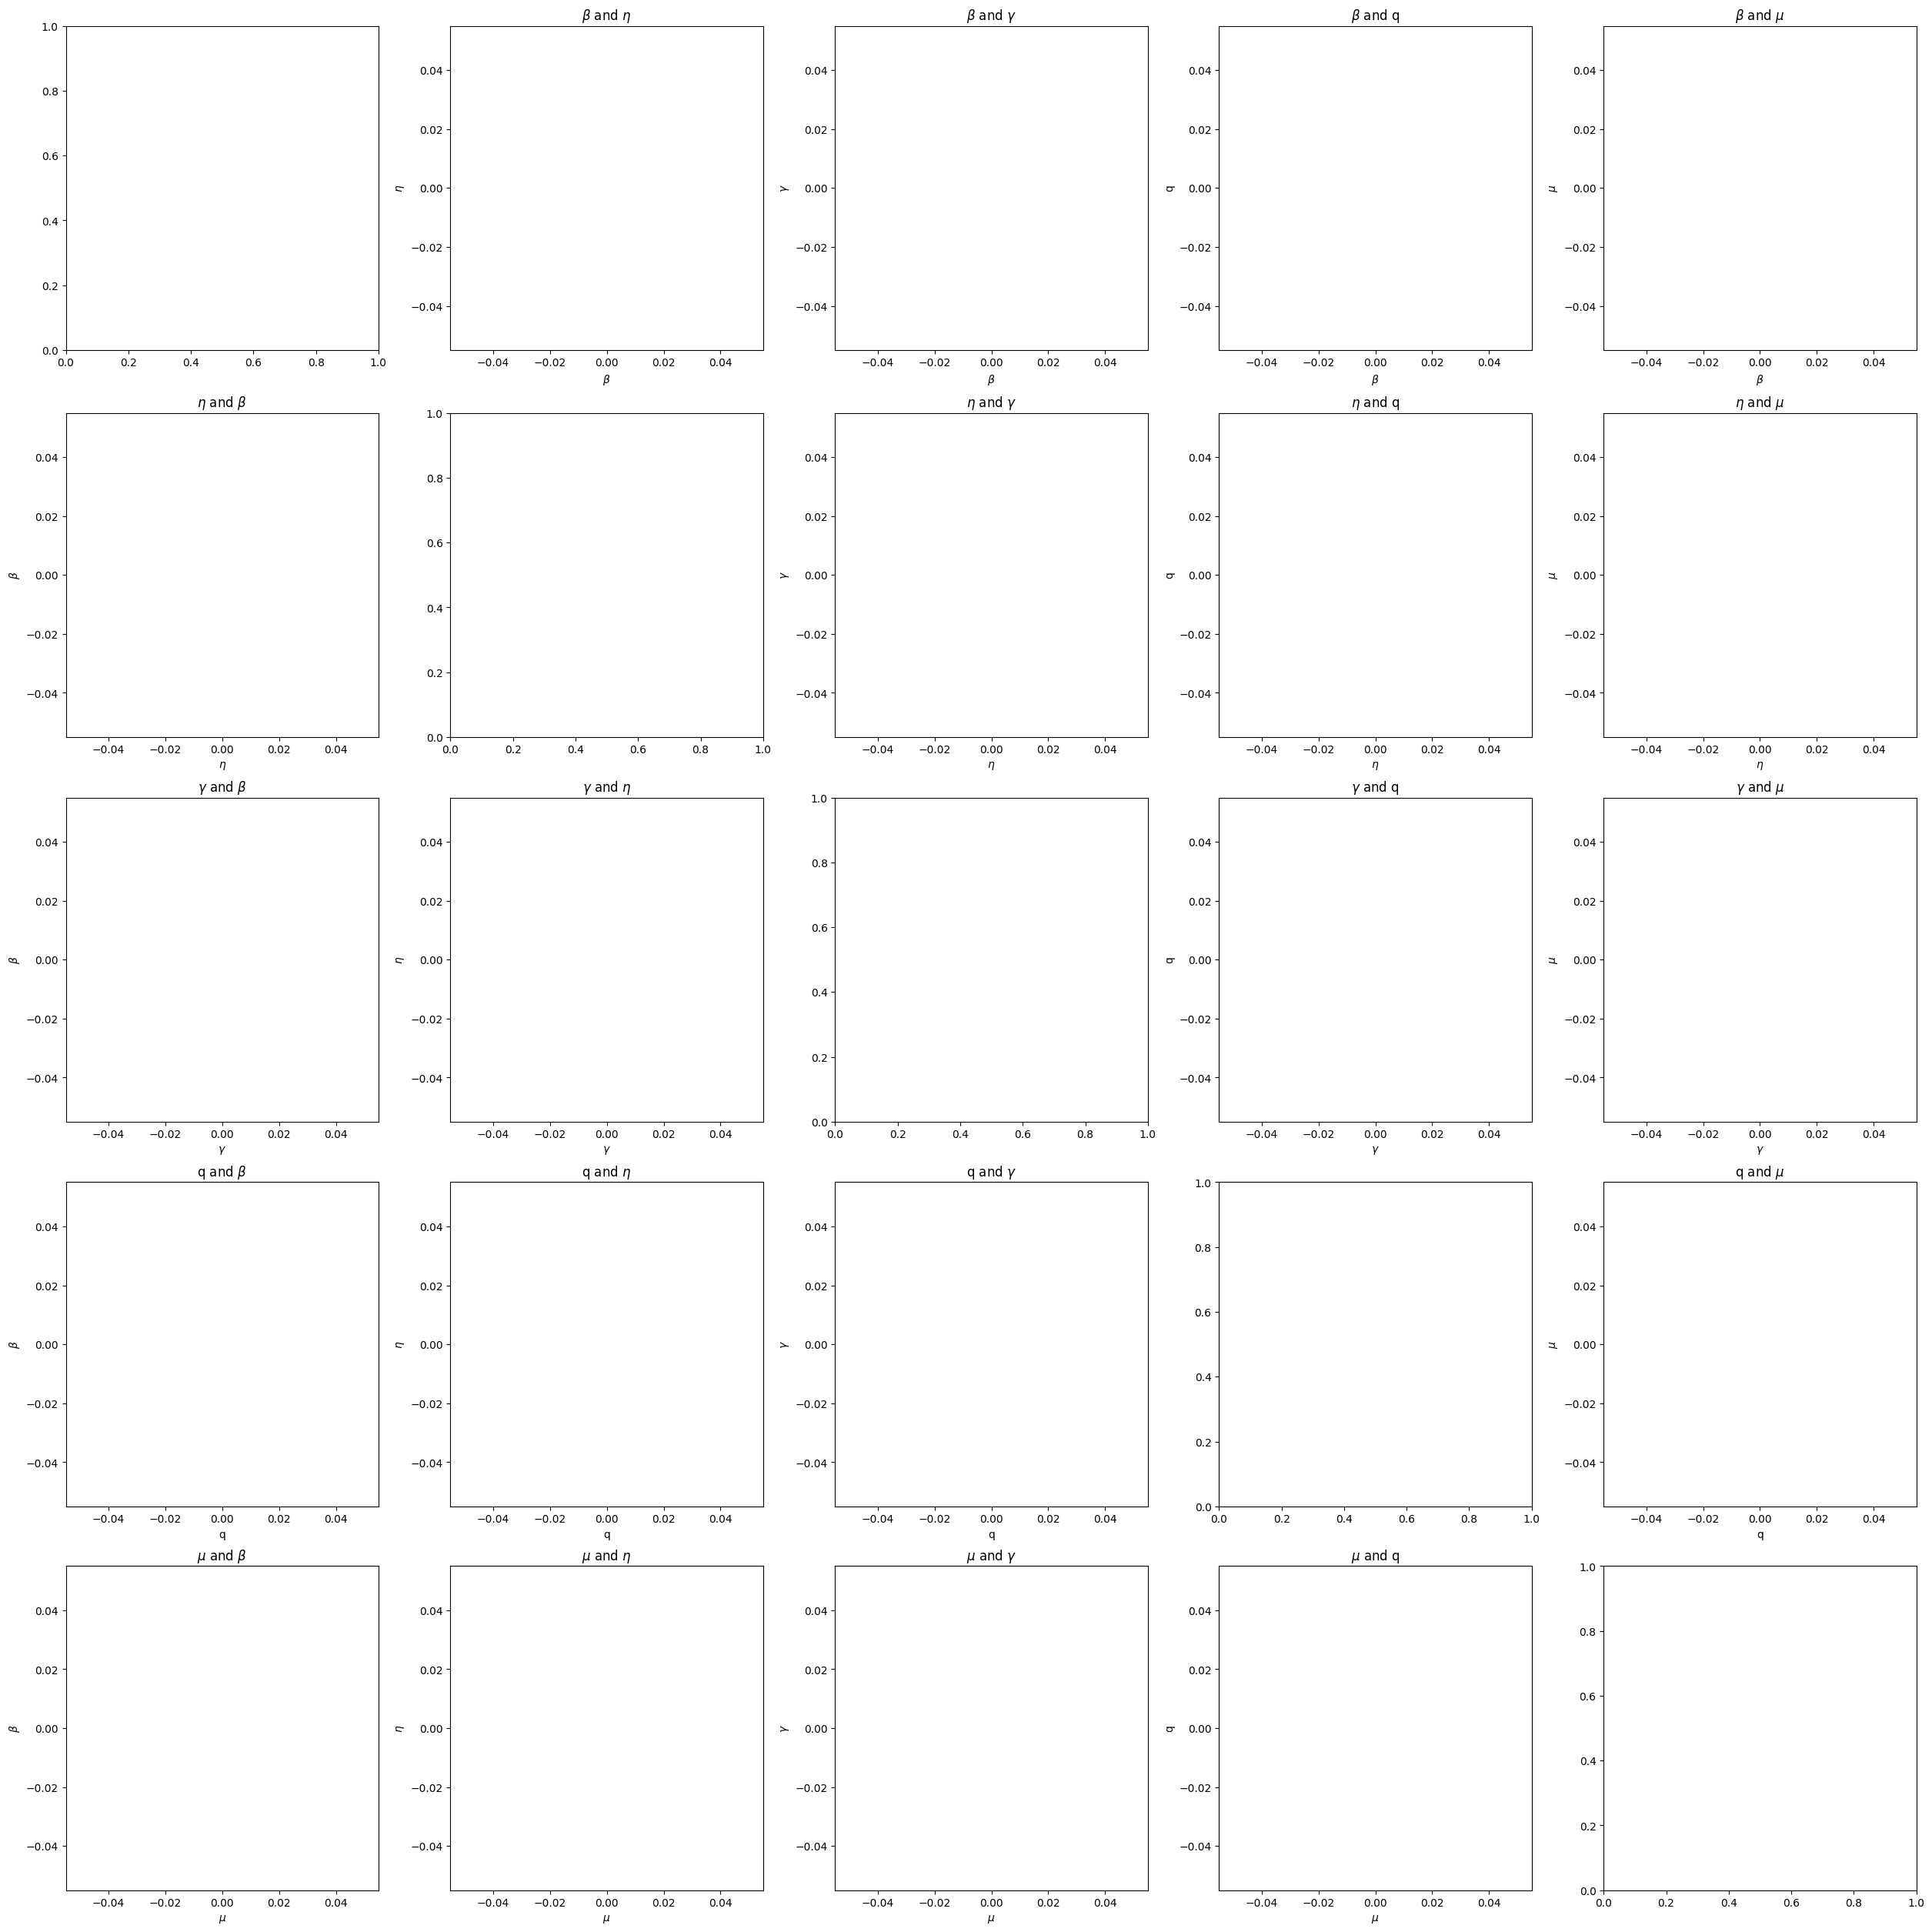

In [ ]:
fig, axes = plt.subplots(D, D, figsize=(5*D, 5*D),layout="constrained")

par_names = ["$\\beta$", "$\\eta$", "$\\gamma$", "q", "$\\mu$"]


for par1_index in range(D):
    for par2_index in range(D):

        if par1_index != par2_index: 
            axes[par1_index, par2_index].set_title(
                f"{par_names[par1_index]} and {par_names[par2_index]}"
            )
            axes[par1_index, par2_index].scatter(
                svgd_samples[:, par1_index],
                svgd_samples[:, par2_index],
                s = 0.5
            )
            axes[par1_index, par2_index].set_xlabel(f"{par_names[par1_index]}")
            axes[par1_index, par2_index].set_ylabel(f"{par_names[par2_index]}")

plt.show()
